<a href="https://colab.research.google.com/github/Felipe-Ulloa-CA/bus-eta-prediction/blob/main/bus_eta_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BUS ETA PREDICTION – FULL NOTEBOOK STRUCTURE

# Executive Summary

This study evaluates whether machine learning models using structural GTFS features can improve bus trip duration prediction compared to traditional schedule-based estimation.

Using official GTFS data from Santiago, Chile, a Random Forest baseline model achieved:

- 15.9% reduction in RMSE compared to Linear Regression
- R² = 0.308 (30.8% of variance explained)

Results demonstrate that structural route features partially explain trip duration variability. However, significant unexplained variance remains, suggesting the need for dynamic operational features for high-precision ETA systems.



# Introduction

## Problem Statement

Santiago’s public transportation system frequently relies on schedule-based ETA predictions, which often fail to reflect real operational variability.

## Research Question

Can machine learning models using GTFS-derived structural features reduce ETA prediction error compared to traditional schedule-based estimation?


# Data Sources

The primary data source is the official GTFS dataset published by the Dirección de Transporte Público Metropolitano (DTPM), Chile.

Key files used in this analysis include:

- stop_times.txt – stop-level timestamps
- trips.txt – trip-level metadata
- routes.txt
- calendar.txt
- transfers.txt

These files allow reconstruction of trip durations and structural route characteristics used in baseline modeling.


In [186]:
# Core libraries
import os
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




In [187]:
from google.colab import drive
drive.mount('/content/drive')
data_path = "/content/drive/MyDrive/bus_eta_project/data"

data_path = "/content/drive/MyDrive/bus_eta_project/data"

print(os.listdir(data_path))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['trips.txt', 'pathways.txt', 'frequencies.txt', 'stop_times.txt', 'agency.txt', 'calendar_dates.txt', 'transfers.txt', 'shapes.txt', 'stops.txt', 'calendar.txt', 'routes.txt', 'feed_info.txt']


In [188]:
stop_times = pd.read_csv(
    f"{data_path}/stop_times.txt",
    usecols=["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"],
    dtype={
        "trip_id": "string",
        "stop_id": "string",
        "stop_sequence": "int32"
    }
)

trips = pd.read_csv(
    f"{data_path}/trips.txt",
    dtype={"trip_id": "string"}
)

stop_times.shape


(845952, 5)

In [189]:
stop_times = pd.read_csv(
    "/content/drive/MyDrive/bus_eta_project/data/stop_times.txt",
    usecols=["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"],
    dtype={
        "trip_id": "string",
        "stop_id": "string",
        "stop_sequence": "int32"
    }
)

trips = pd.read_csv(
    "/content/drive/MyDrive/bus_eta_project/data/trips.txt",
    dtype={"trip_id": "string"}
)

print(stop_times.shape)



(845952, 5)


In [190]:
def time_to_seconds(t):
    try:
        h, m, s = map(int, t.split(":"))
        return h*3600 + m*60 + s
    except:
        return None

stop_times["arrival_seconds"] = stop_times["arrival_time"].apply(time_to_seconds)



In [191]:
trip_duration = (
    stop_times
    .groupby("trip_id")
    .agg(
        start_time=("arrival_seconds", "min"),
        end_time=("arrival_seconds", "max")
    )
)

trip_duration["trip_duration_seconds"] = (
    trip_duration["end_time"] - trip_duration["start_time"]
)

trip_duration = trip_duration[
    trip_duration["trip_duration_seconds"] > 0
]

model_data = trip_duration.merge(trips, on="trip_id")



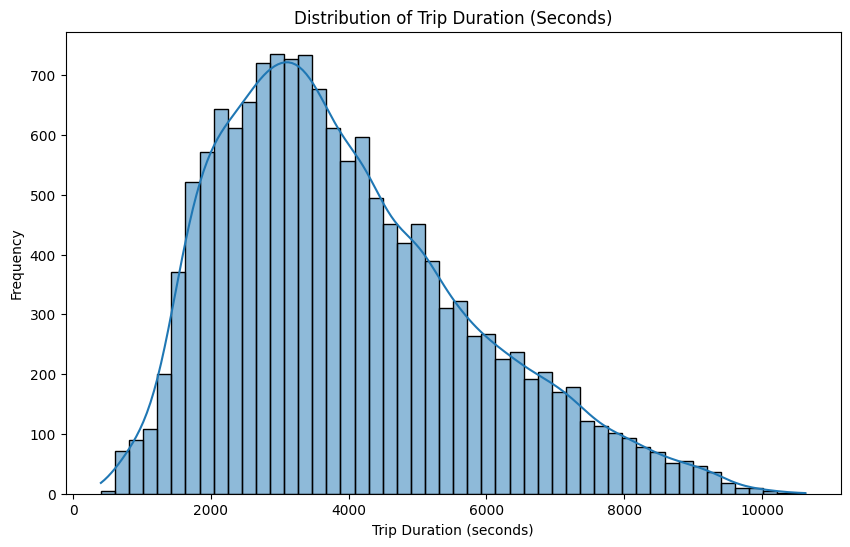

In [192]:
# Distribution of trip duration
plt.figure(figsize=(10,6))
sns.histplot(model_data["trip_duration_seconds"], bins=50, kde=True)
plt.title("Distribution of Trip Duration (Seconds)")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()


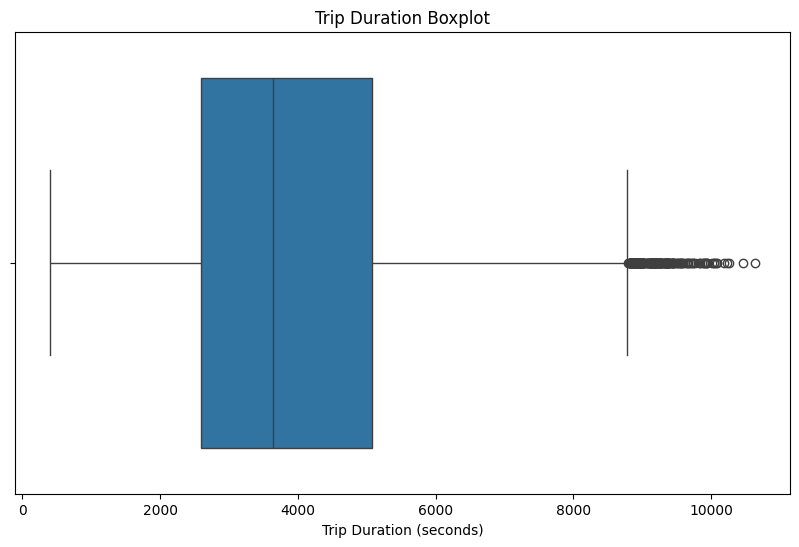

In [193]:
# Boxplot for outlier visualization
plt.figure(figsize=(10,6))
sns.boxplot(x=model_data["trip_duration_seconds"])
plt.title("Trip Duration Boxplot")
plt.xlabel("Trip Duration (seconds)")
plt.show()


# Data Cleaning

Duplicate records were removed to prevent modeling bias.

Missing values were inspected. While some variables (e.g., wheelchair_accessible, bikes_allowed) contain missing values, these were not used in the baseline modeling features.

Selected modeling features contain no missing values; therefore, no imputation was required.


In [194]:
model_data = model_data[
    model_data["trip_duration_seconds"] < 3 * 3600
]


In [195]:
model_data["trip_duration_minutes"] = model_data["trip_duration_seconds"] / 60
model_data["is_weekend"] = model_data["service_id"].isin(["S", "D"]).astype(int)

route_trip_count = model_data.groupby("route_id").size()
model_data["route_trip_count"] = model_data["route_id"].map(route_trip_count)


In [196]:
features = [
    "direction_id",
    "is_weekend",
    "route_trip_count"
]

X = model_data[features]
y = model_data["trip_duration_seconds"]


In [197]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [198]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))


In [199]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


In [200]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE (sec)": [mae_lr, mae_rf],
    "RMSE (sec)": [rmse_lr, rmse_rf],
    "R²": [None, r2_rf]
}).round(2)

results


,Model,MAE (sec),RMSE (sec),R²
0,Linear Regression,1480.75,1831.71,NaN
1,Random Forest,1209.44,1540.75,0.31


In [201]:
improvement = (rmse_lr - rmse_rf) / rmse_lr * 100
print(f"Random Forest RMSE improvement: {improvement:.2f}%")


Random Forest RMSE improvement: 15.88%


In [202]:
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df


,Feature,Importance
2,route_trip_count,0.928198
1,is_weekend,0.048846
0,direction_id,0.022955


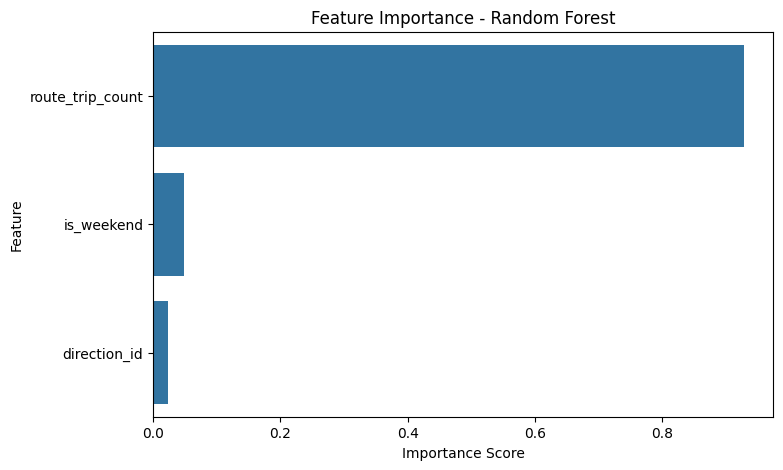

In [203]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [204]:
residuals = y_test - y_pred_rf


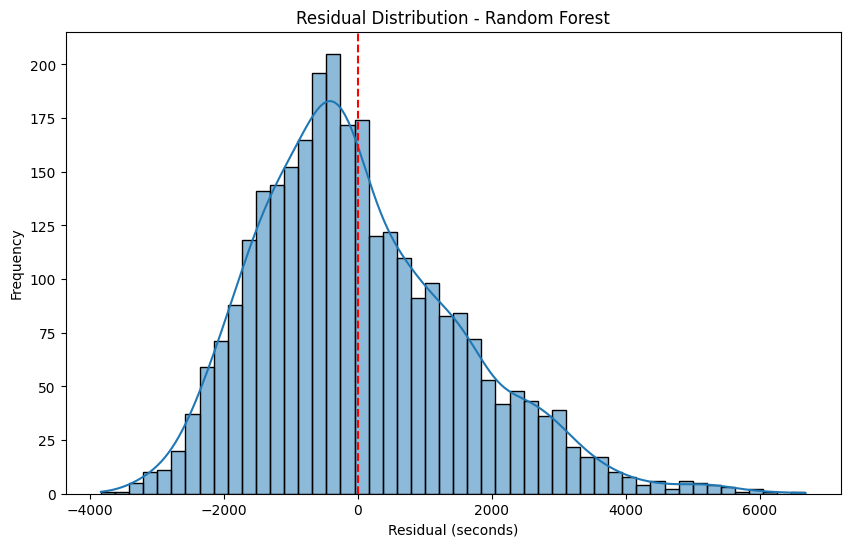

In [205]:


plt.figure(figsize=(10,6))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution - Random Forest")
plt.xlabel("Residual (seconds)")
plt.ylabel("Frequency")
plt.show()


# Residual Analysis

Residuals are approximately centered around zero, indicating limited systematic bias.

However, positive skew suggests underestimation in certain high-variability trips.

Large residuals (>4000 seconds) likely reflect missing operational variables such as congestion and peak-hour effects.


# Discussion and Technical Findings

The Random Forest model reduces RMSE by approximately 15.9% compared to Linear Regression.

Structural GTFS-derived features partially explain trip duration variability (R² = 0.308).

However, significant unexplained variance remains, highlighting the limitations of purely schedule-based modeling.


# Future Improvements

Future iterations should incorporate:

- Real-time GPS data
- Peak-hour indicators
- Segment-level modeling
- Cross-validation and hyperparameter tuning
- Model monitoring for production deployment
